In [1]:
%load_ext autoreload
%autoreload 2
# %matplotlib ipympl
%config InlineBackend.figure_format='retina'

import numpy as np
import networkx as nx
from idtxl.estimators_jidt import JidtDiscreteMI, JidtDiscreteCMI
import matplotlib.pyplot as plt
import os, sys
os.environ['JAVA_HOME'] = '/Users/jaime/miniconda3/envs/ma-aif-dit/lib/jvm'

In [2]:
%store -r all_partition_timeseries

## Krakauer et al. individuality

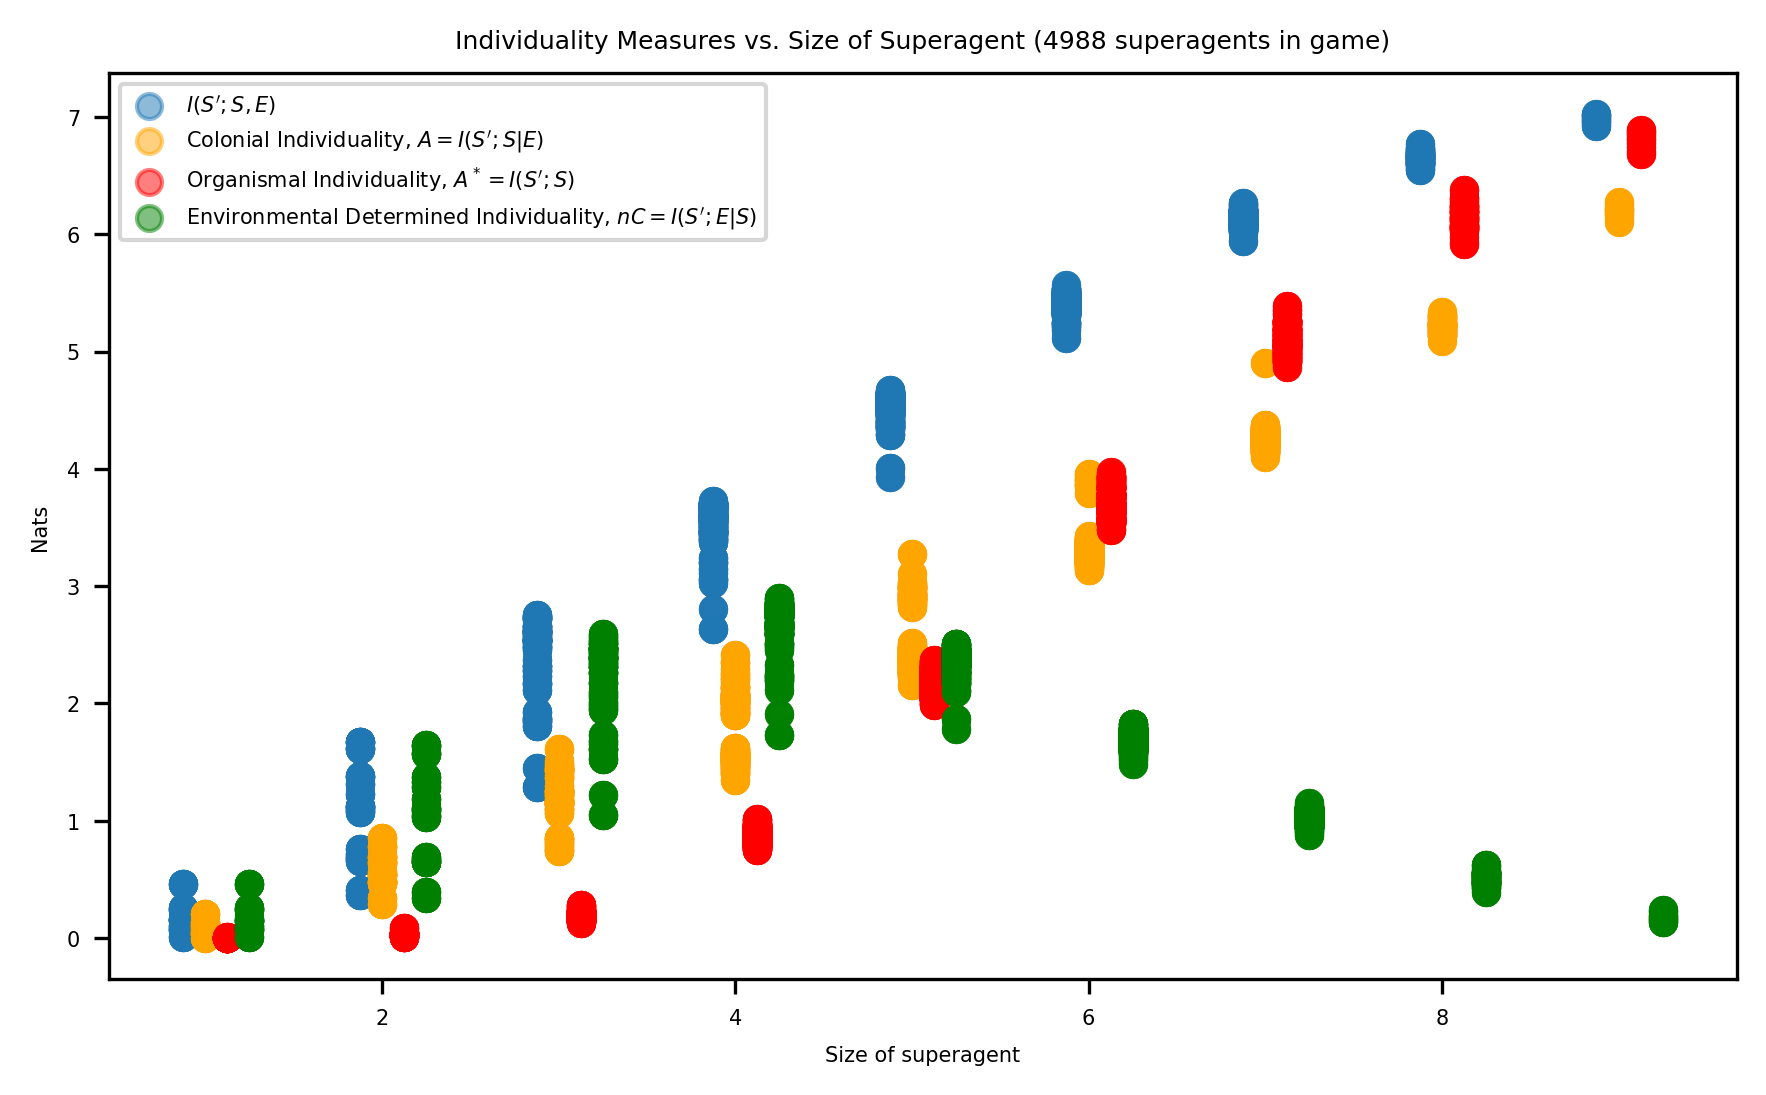

In [3]:
plt.figure(figsize=(7, 4), dpi=150)

plt.rcParams.update({'font.size': 5})

# I(S, E; S') ------------------------------------------------------------------
results_vanilla = []
for S_history, E_history in all_partition_timeseries:
    mi_estimator = JidtDiscreteMI()
    source = np.hstack((S_history[:-1], E_history[:-1]))
    target = S_history[1:]
    try:
        mi_result = mi_estimator.estimate(source, target)
    except AssertionError as e:
        print(f"AssertionError: {e}")
        print(f"Source shape: {source.shape}")
        print(f"Target shape: {target.shape}")
        print(f"Source: {source}")
        print(f"Target: {target}")
        print(f"S_history shape: {S_history.shape}")
        print(f"E_history shape: {E_history.shape}")
        raise e
    results_vanilla.append((mi_result, S_history.shape[1], E_history.shape[1]))

x = [r[1]-0.125 for r in results_vanilla]
y = [r[0] for r in results_vanilla]
plt.scatter(x, y, alpha=0.5, label="$I(S'; S, E)$")

# I(S'; S | E) --------------------------------------------------------------
results_colonial = []
for S_history, E_history in all_partition_timeseries:
    cmi_estimator = JidtDiscreteCMI()
    source = S_history[:-1]
    target = S_history[1:]
    mi_result = cmi_estimator.estimate(source, target, conditional=E_history[:-1])
    results_colonial.append((mi_result, S_history.shape[1], E_history.shape[1]))

x = [r[1] for r in results_colonial]
y = [r[0] for r in results_colonial]
plt.scatter(x, y, alpha=0.5, c='orange', label="Colonial Individuality, $A = I(S'; S | E)$")

# I(S'; S | E) --------------------------------------------------------------
results_organismal = []
for S_history, E_history in all_partition_timeseries:
    mi_estimator = JidtDiscreteMI()
    source = S_history[:-1]
    target = S_history[1:]
    mi_result = mi_estimator.estimate(source, target)
    results_organismal.append((mi_result, S_history.shape[1], E_history.shape[1]))

x = [r[1]+0.125 for r in results_organismal]
y = [r[0] for r in results_organismal]
plt.scatter(x, y, alpha=0.5, c='red', label="Organismal Individuality, $A^*=I(S' ; S)$")

# I(S'; E | S) --------------------------------------------------------------
results_environmental = []
for S_history, E_history in all_partition_timeseries:
    cmi_estimator = JidtDiscreteCMI()
    source = E_history[:-1]
    target = S_history[1:]
    mi_result = cmi_estimator.estimate(source, target, conditional=S_history[:-1])
    results_environmental.append((mi_result, S_history.shape[1], E_history.shape[1]))

x = [r[1]+0.25 for r in results_environmental]
y = [r[0] for r in results_environmental]
plt.scatter(x, y, alpha=0.5, c='green', label="Environmental Determined Individuality, $nC=I(S'; E | S)$")

# Create a scatterplot ---------------------------------------------------------
plt.legend()
plt.ylabel('Nats')
plt.xlabel('Size of superagent')
plt.title(f'Individuality Measures vs. Size of Superagent ({len(all_partition_timeseries)} superagents in game)')
plt.show()

Interpretation: The magnitude of the green points has to do with the ratio of superagent size to environment size. The larger the superagent, the less "environment nodes" are left for it to interact with. For example, for a 10 agent simulation, a size-9 superagent only interacts with 1 environment node. 

## PID individuality

In [4]:
import pandas as pd

from dit import Distribution
from dit.pid import *

In [5]:
unique_infos = []
for S_history, E_history in all_partition_timeseries:
# S_history, E_history = all_partition_timeseries[45]
    print('superagent size', S_history.shape[1])

    # Data setup -------------------------------------------------
    all_data = np.hstack((S_history[:-1], S_history[1:], E_history[:-1], E_history[1:]))

    m = S_history.shape[1]
    if m > 4:
        # Compute struggles with larger superagents
        break

    V = all_data[:, :m].mean(axis=1)

    # Create column names for S_history and E_history
    s_columns = [f"S_{i}" for i in range(S_history.shape[1])]
    s_next_columns = [f"S_{i}_" for i in range(S_history.shape[1])]
    e_columns = [f"E_{i}" for i in range(E_history.shape[1])]
    e_next_columns = [f"E_{i}_" for i in range(E_history.shape[1])]
    column_names = s_columns + s_next_columns + e_columns + e_next_columns + ['V']

    # Combine S_history and E_history into a single DataFrame
    df = pd.DataFrame(
        np.hstack((all_data, V.reshape(-1, 1))), 
        columns=column_names
    )

    # Get distribution from DataFrame
    counts = df.value_counts()
    outcomes = list(counts.index)
    probs = list(counts / counts.sum())
    dist = Distribution(outcomes, probs)

    # Shorthand function to get the index of a column
    idx = lambda x: column_names.index(x)

    # Compute PID ------------------------------------------------------------------
    sources = [
        (idx('V'),), 
        tuple([idx(f'S_{i}') for i in range(m)]), 
    ]
    target = tuple([idx(f'S_{i}_') for i in range(m)])

    pid_obj = PID_BROJA(dist, sources, target)

    # synergy = pid_obj.get_pi(
    #     ( sources[0] + sources[1], ) 
    # )
    # redundancy = pid_obj.get_red(tuple(sources))

    # TODO: level-k
    unique_info = pid_obj.get_pi(
        (sources[1], )
    )
    # unique_info = pid_obj.get_pi(
        # (tuple([idx(f'S_{i}_') for i in range(m)]), )
    # )

    # unique_infos = np.empty((2,))
    # for i in range(2):
    #     unique_infos[i] = pid_obj.get_pi(((i,),))

    # Also compute total MI (sum synergy, redundancy, unique X1, unique X2)
    # total_mi = (
    #     synergy
    #     + redundancy
    #     + unique_infos.sum()
    # )
    unique_infos.append(unique_info)

superagent size 1
superagent size 1
superagent size 1
superagent size 1
superagent size 1
superagent size 2
superagent size 2
superagent size 2
superagent size 2
superagent size 2
superagent size 2
superagent size 2
superagent size 2
superagent size 3
superagent size 3
superagent size 3
superagent size 3
superagent size 3
superagent size 3


KeyboardInterrupt: 

In [6]:
label_font_size = 6

# matplotlib.use("pgf")
plt.rcParams.update({
    'xtick.labelsize': label_font_size,
    'ytick.labelsize': label_font_size,
    'axes.linewidth': 0.5,
    'font.family': 'serif',
    'text.usetex': True,
    'text.latex.preamble': r'''
        \usepackage{amssymb} 
        \usepackage{amsmath} 

        % Load Libertine fonts for text and math
        \usepackage[tt=false]{libertine}   % Libertine for text (not for monospaced)
        \usepackage[libertine]{newtxmath}  % Libertine for math

        % Load Inconsolata for monospaced text
        \usepackage{inconsolata}

        % Redefine \mathtt to use Inconsolata in math mode
        \renewcommand{\mathtt}[1]{\text{\texttt{#1}}}
    ''',
    'figure.dpi': 300,
    'pgf.texsystem': 'pdflatex',
    'pgf.rcfonts': False,
    'ps.usedistiller': 'xpdf',
})

Text(0.5, 1.0, 'Unique Information vs. Size of Superagent (data for only 18 superagents)')

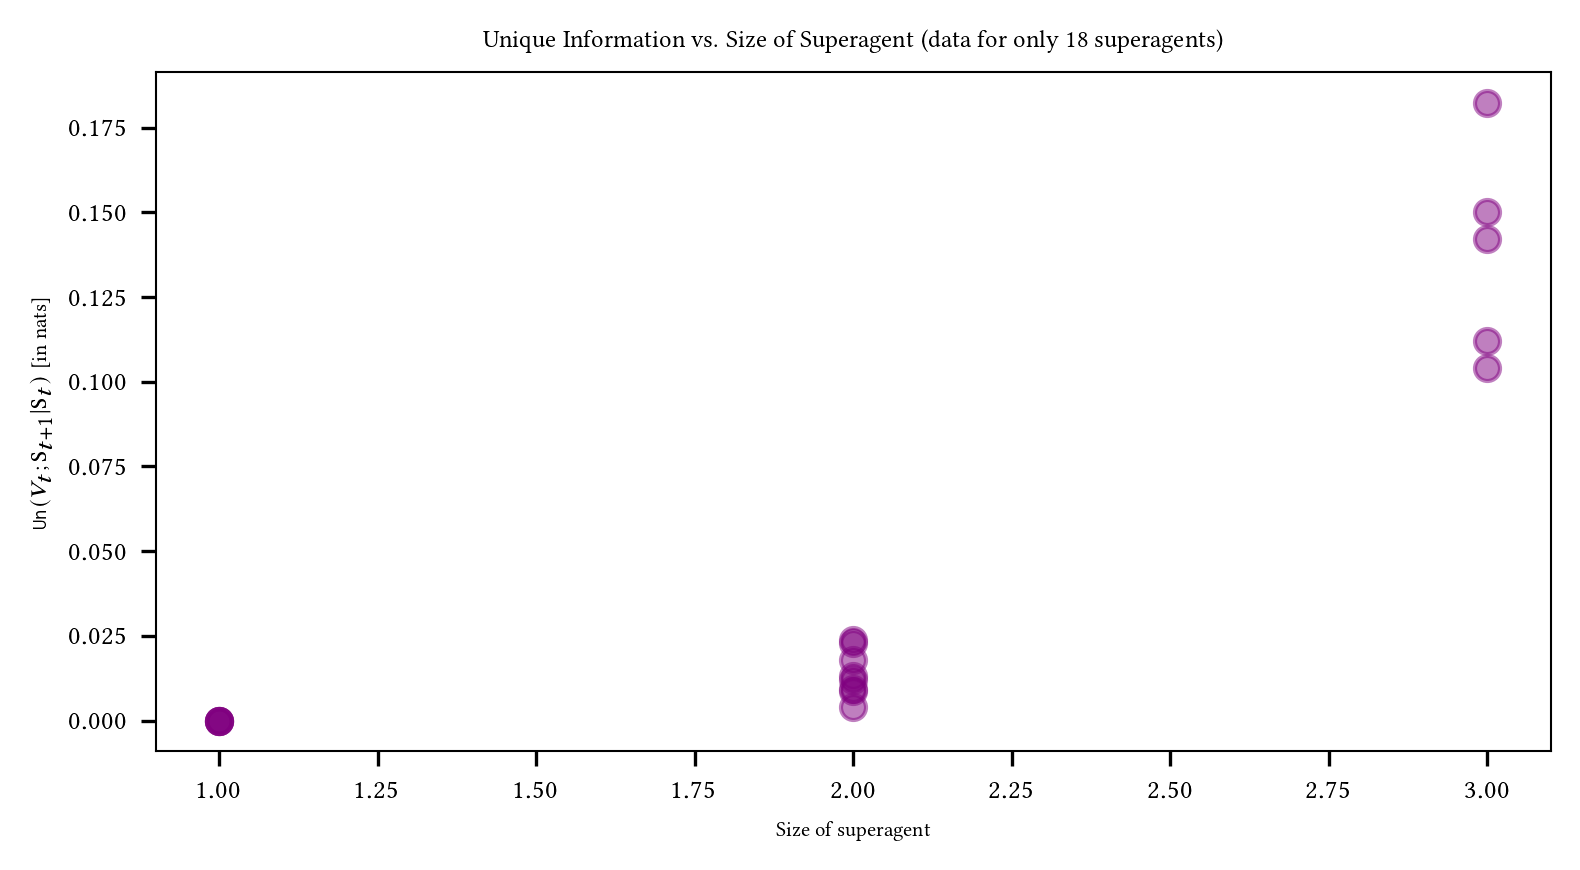

In [7]:
superagent_sizes = np.array([s.shape[1] for s, e in all_partition_timeseries])
plt.figure(figsize=(6, 3), dpi=150)
plt.scatter(
    superagent_sizes[:len(unique_infos)], 
    unique_infos, 
    alpha=0.5, 
    c='purple', 
    label="Unique Information"
)
plt.xlabel('Size of superagent')
plt.ylabel(r'$\texttt{Un}(V_t; \mathbf{S}_{t+1} | \mathbf{S}_t)$ [in nats]')
plt.title(f'Unique Information vs. Size of Superagent (data for only {len(unique_infos)} superagents)')

## IIT

The following measure is a sufficient condition for "causal emergence":

$$
\Psi = I(V_t; V_{t+1}) - \sum_i I(X^i_t; V_{t+1})
$$

* This is Eq. 10a in [@Rosas2020ReconcilingEmergences](https://journals.plos.org/ploscompbiol/article?id=10.1371/journal.pcbi.1008289#sec003)
* See also Eq. 1 in [@McSharry2024LearningDiverse](https://proceedings.neurips.cc/paper_files/paper/2024/hash/d8398f4da88975e2a9c62ecaa5ba267b-Abstract-Conference.html)

⚠️ The question remains: how to select the right coarse-graining $V = f(X)$? [@McSharry2024LearningDiverse](https://proceedings.neurips.cc/paper_files/paper/2024/hash/d8398f4da88975e2a9c62ecaa5ba267b-Abstract-Conference.html) addresses this with deep learning.

In [27]:
mappings = {
    'mean': lambda x: x.mean(axis=1),
    'max': lambda x: x.max(axis=1),
    'min': lambda x: x.min(axis=1),
    'std': lambda x: x.std(axis=1),
}

results_psi = {k: [] for k in mappings.keys()}

for key, mapping in mappings.items():
    for S_history, E_history in all_partition_timeseries:
        psi = 0
        
        # First (global) term
        num_bins = 10
        mi_estimator = JidtDiscreteMI(
            settings=dict(
                discretise_method='max_ent',
                n_discrete_bins=num_bins,
                )
        )
        V = mappings[key](S_history)
        # Discretize V
        source = V[:-1]
        target = V[1:]
        mi_result = mi_estimator.estimate(source, target)

        psi += mi_result
        
        # Second (local) term
        for i in range(S_history.shape[1]):
            source = S_history[:-1, i]
            target = V[1:]
            mi_result = mi_estimator.estimate(source, target)
            psi -= mi_result

        results_psi[key].append(psi)

KeyboardInterrupt: 

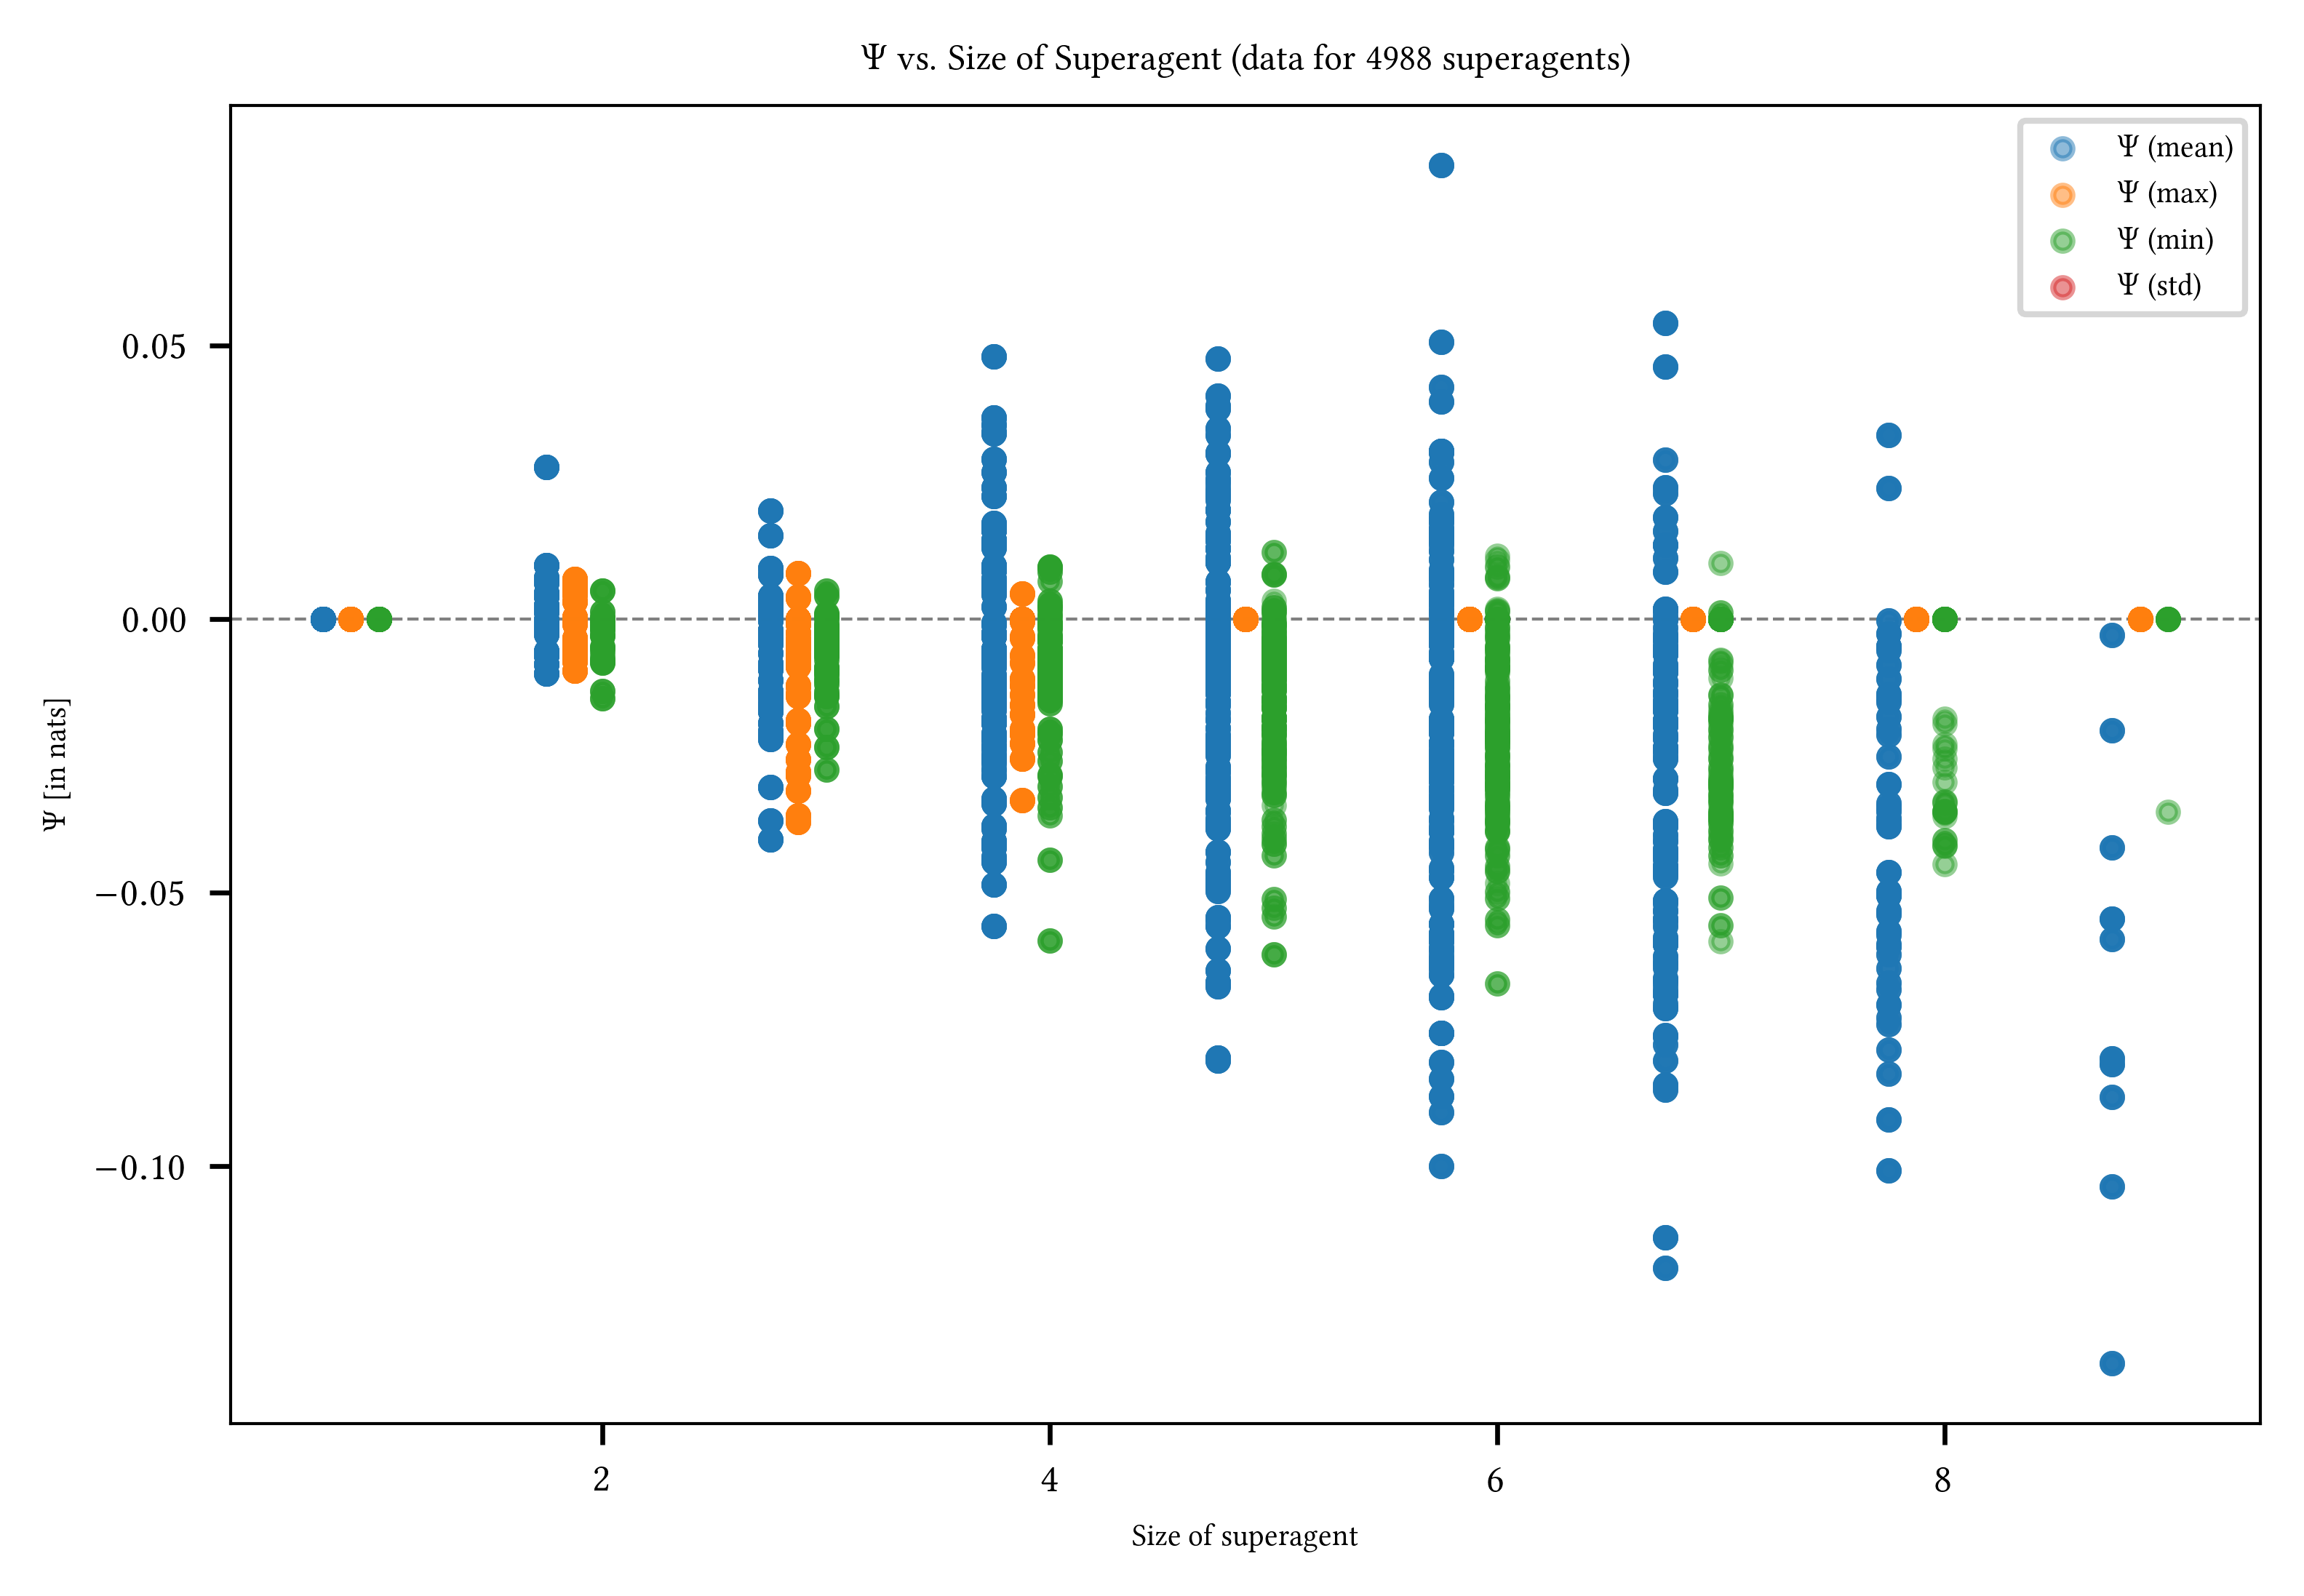

In [28]:
results_psi = {
    k: np.array(v) for k, v in results_psi.items()
}

jitters = np.arange(-0.25, 0.25, 0.125)
for i, (key, result) in enumerate(results_psi.items()):
    plt.scatter(
        superagent_sizes[:len(result)] + jitters[i], 
        result, 
        alpha=0.5, 
        s=10,
        label=f"$\Psi$ ({key})"
    )

plt.axhline(0, color='gray', linestyle='--', linewidth=0.5, zorder=-10)

plt.xlabel('Size of superagent')
plt.ylabel(r'$\Psi$ [in nats]')
plt.title(f'$\Psi$ vs. Size of Superagent (data for {len(results_psi[list(results_psi.keys())[0]])} superagents)')
plt.legend()
plt.show()

### Minimum Mutual Information-adjusted measure

$$
\Psi = I(V_t; V_{t+1}) - \sum_i I(X^i_t; V_{t+1}) + (n-1)\min_i I(X^i_t; V_{t+1})
$$

* Eq. 2 in [@McSharry2024LearningDiverse](https://proceedings.neurips.cc/paper_files/paper/2024/hash/d8398f4da88975e2a9c62ecaa5ba267b-Abstract-Conference.html)

In [12]:
mappings = {
    'mean': lambda x: x.mean(axis=1),
    'max': lambda x: x.max(axis=1),
    'min': lambda x: x.min(axis=1),
    'std': lambda x: x.std(axis=1),
}

results_psi = {k: [] for k in mappings.keys()}

for key, mapping in mappings.items():
    for S_history, E_history in all_partition_timeseries:
        psi = 0
        
        # First (global) term
        num_bins = 10
        mi_estimator = JidtDiscreteMI(
            settings=dict(n_discrete_bins=num_bins)
        )
        V = mappings[key](S_history)
        # Discretize V
        V = np.digitize(V, bins=np.linspace(V.min(), V.max(), num_bins)).astype(np.int32) - 1
        source = V[:-1]
        target = V[1:]
        mi_result = mi_estimator.estimate(source, target)

        psi += mi_result
        
        # Second (local) term
        local_mi_results = []
        for i in range(S_history.shape[1]):
            mi_estimator = JidtDiscreteMI(
                settings=dict(n_discrete_bins=num_bins)
            )
            source = S_history[:-1, i]
            target = V[1:]
            mi_result = mi_estimator.estimate(source, target)
            local_mi_results.append(mi_result)
            psi -= mi_result

        # Third term: MMI adjustment
        local_mi_results = np.array(local_mi_results)
        psi += len(local_mi_results) * local_mi_results.min()

        results_psi[key].append(psi)

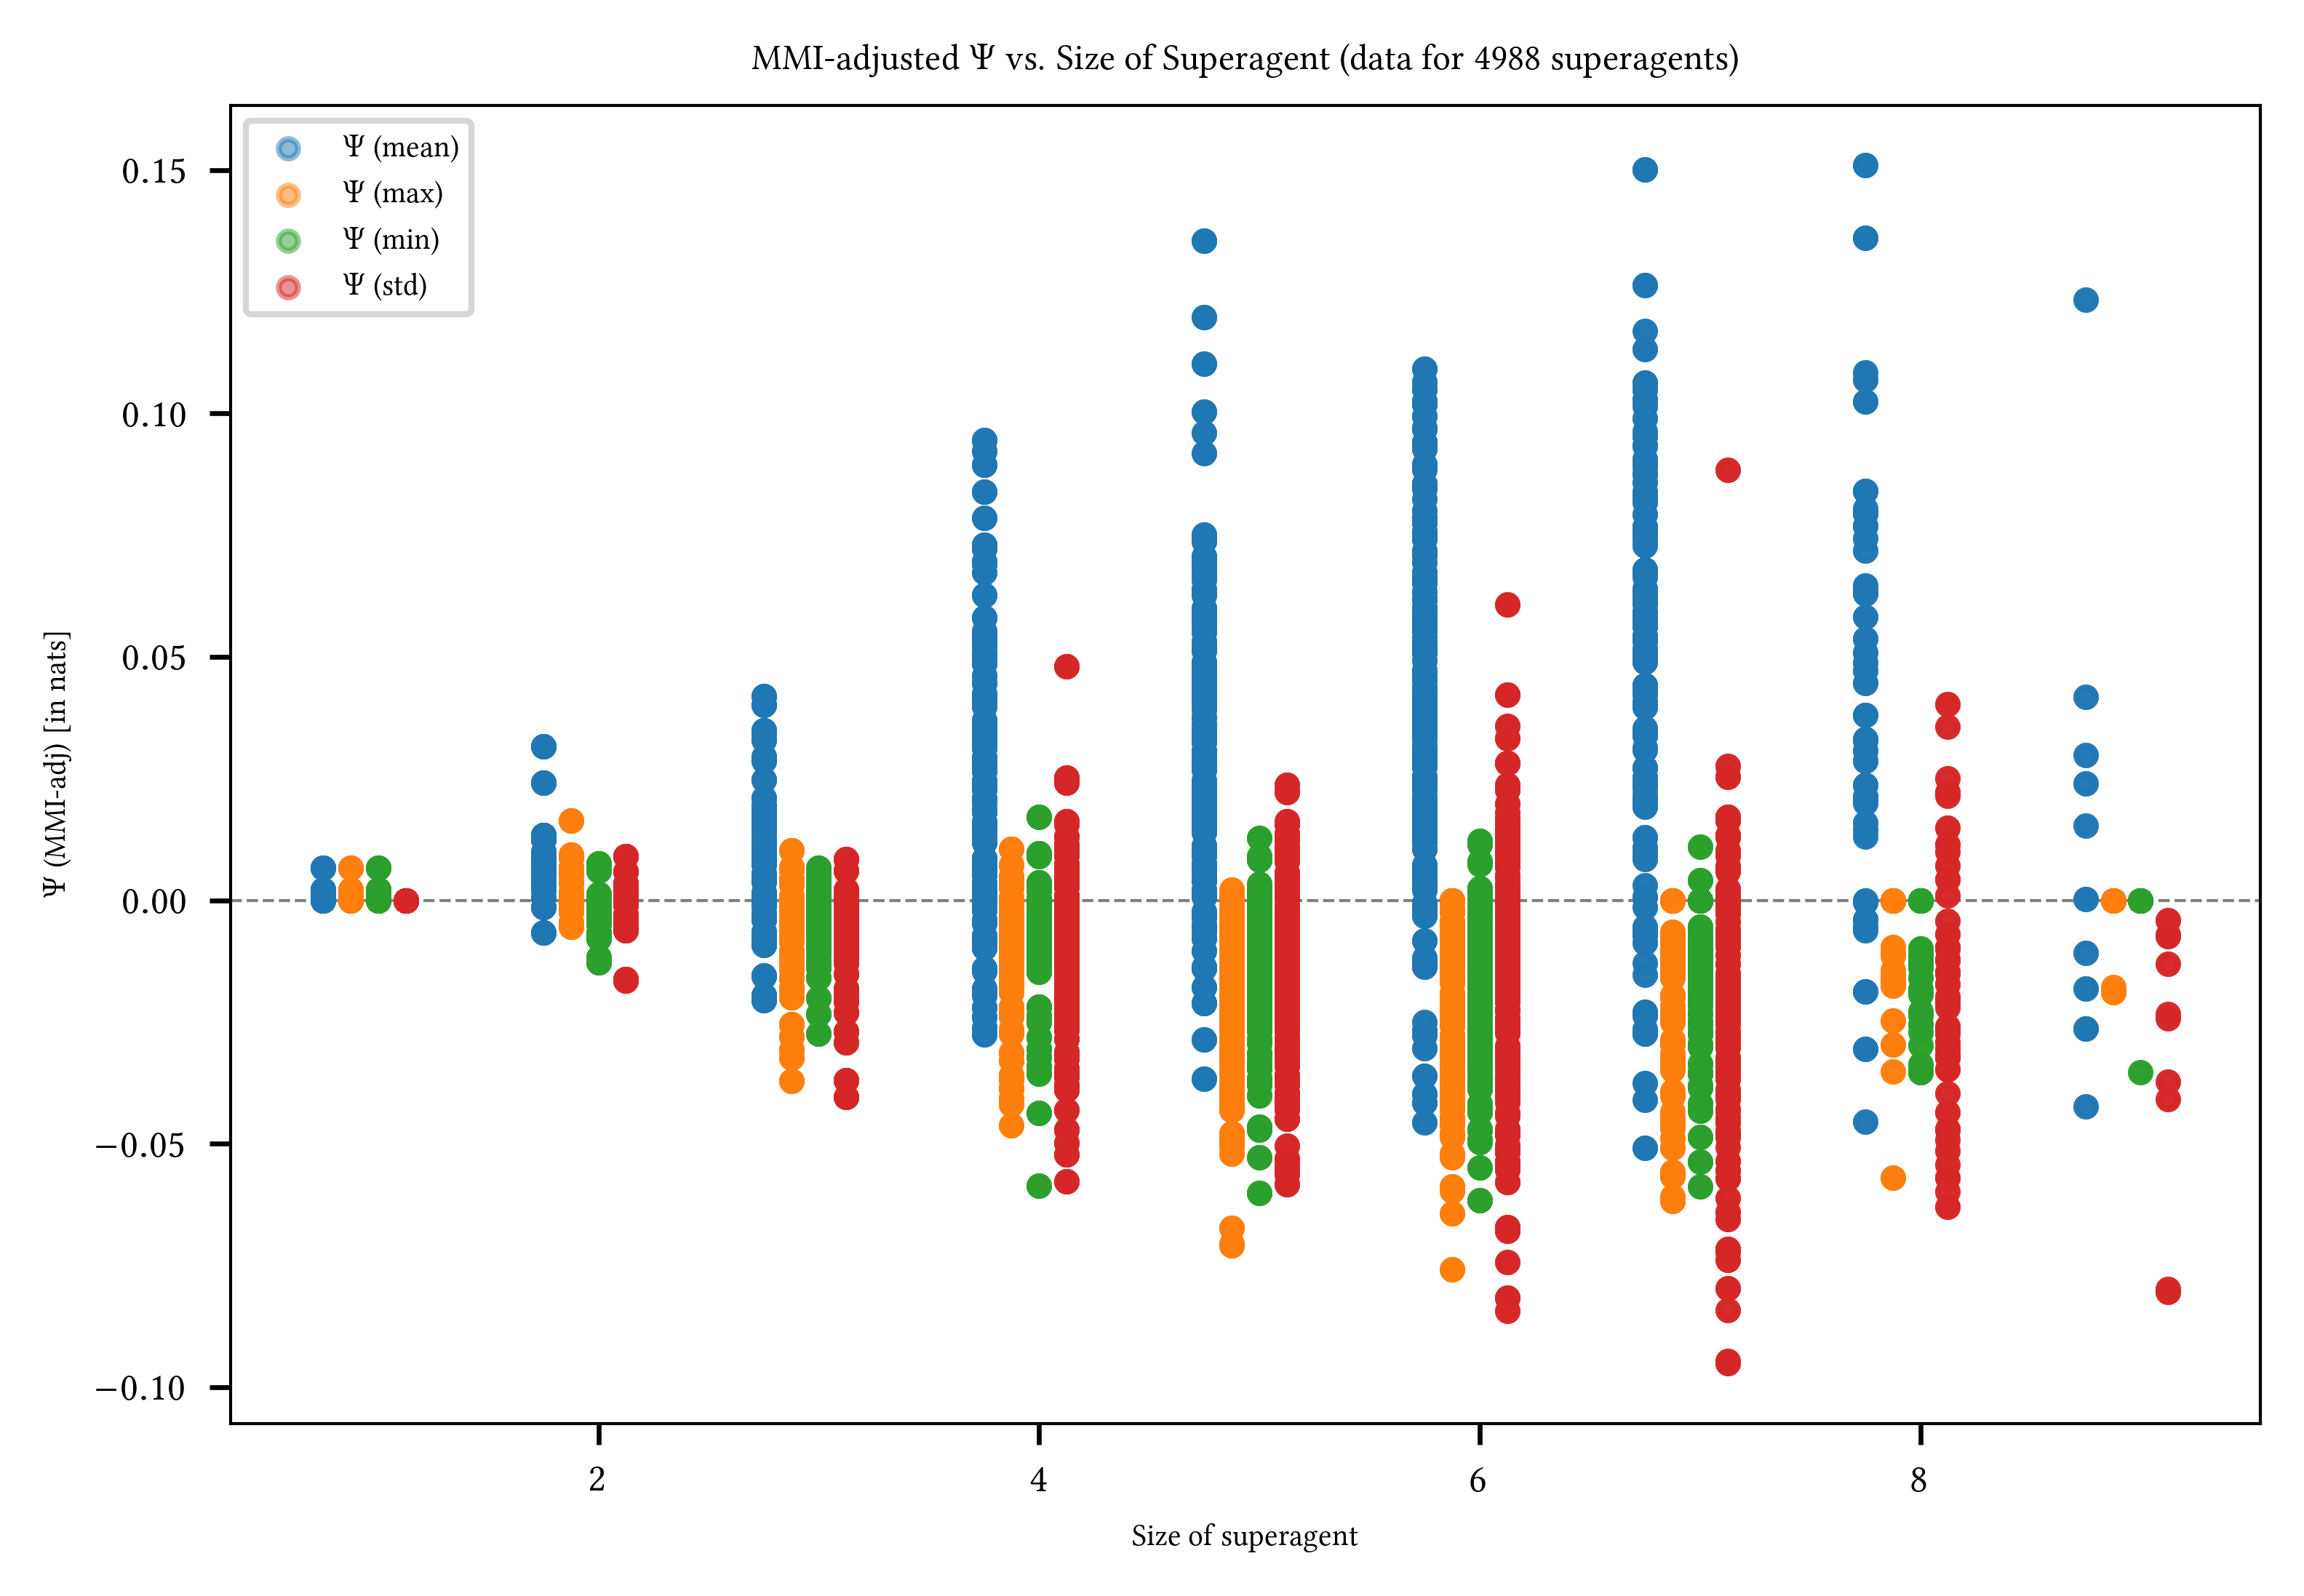

In [11]:
results_psi = {
    k: np.array(v) for k, v in results_psi.items()
}

jitters = np.arange(-0.25, 0.25, 0.125)
for i, (key, result) in enumerate(results_psi.items()):
    plt.scatter(
        superagent_sizes[:len(result)] + jitters[i], 
        result, 
        alpha=0.5, 
        s=10,
        label=f"$\Psi$ ({key})"
    )

plt.axhline(0, color='gray', linestyle='--', linewidth=0.5, zorder=-10)

plt.xlabel('Size of superagent')
plt.ylabel(r'$\Psi$ (MMI-adj) [in nats]')
plt.title(f'MMI-adjusted $\Psi$ vs. Size of Superagent (data for {len(results_psi[list(results_psi.keys())[0]])} superagents)')
plt.legend()
plt.show()

## IDEA: how much does each agent contribute to the superagent? 

I.e. what is the relative $I(X_i; V)$ for each agent $i$?

In [33]:
num_bins = 10
mi_estimator = JidtDiscreteMI(settings=dict(
    n_discrete_bins=num_bins,
    discretise_method='max_ent',
))

all_contributions = []
for data in all_partition_timeseries:
    X = data[0]
    Y = data[1]

    V = X.mean(axis=1)

    local_mi_results = []
    for i in range(X.shape[1]):
        source = X[:-1, i]
        target = V[1:]
        local_mi_results.append(mi_estimator.estimate(source, target))

    contributions = np.array(local_mi_results) / np.sum(local_mi_results)
    all_contributions.append(contributions)

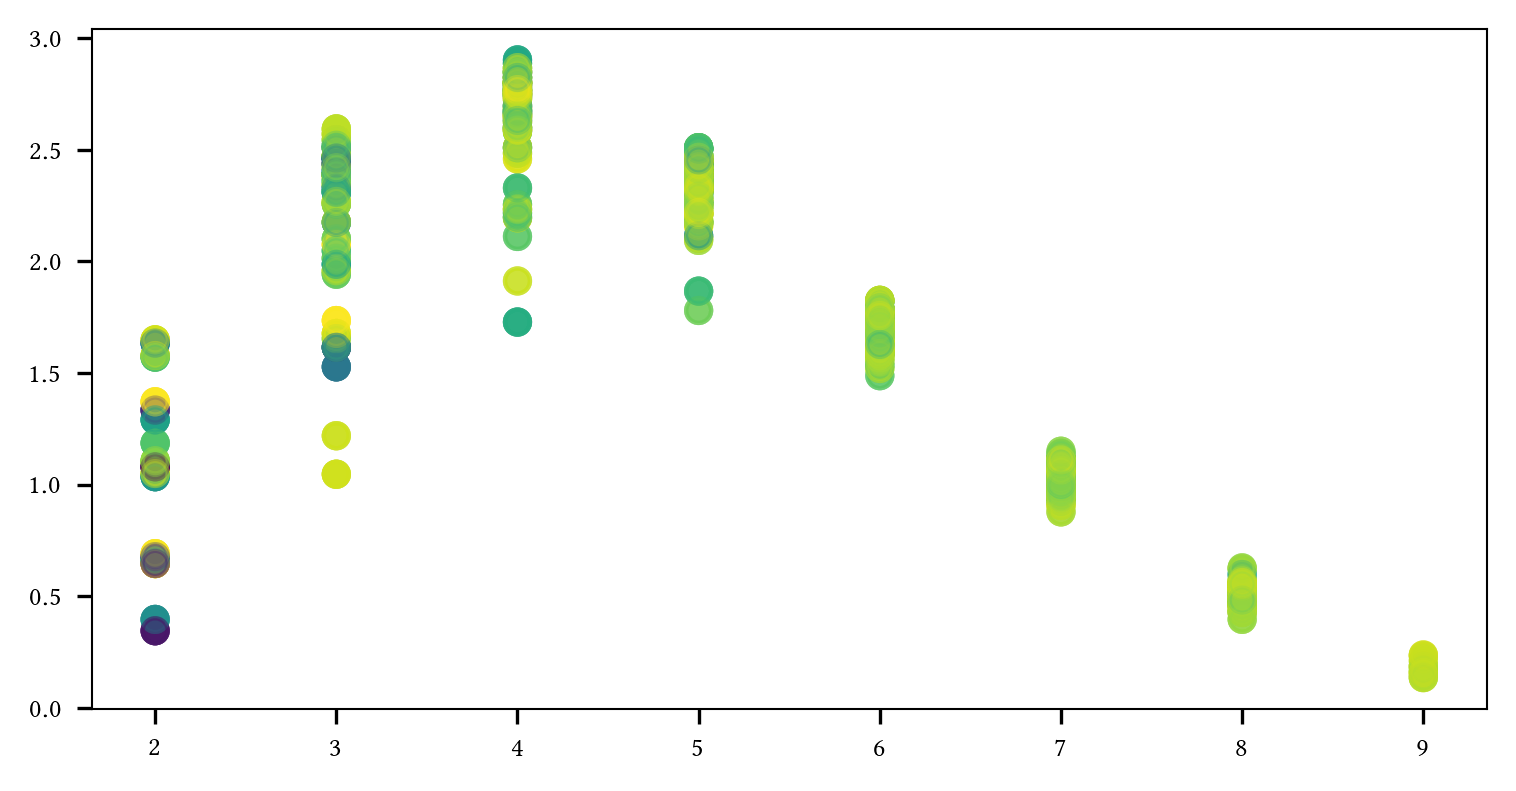

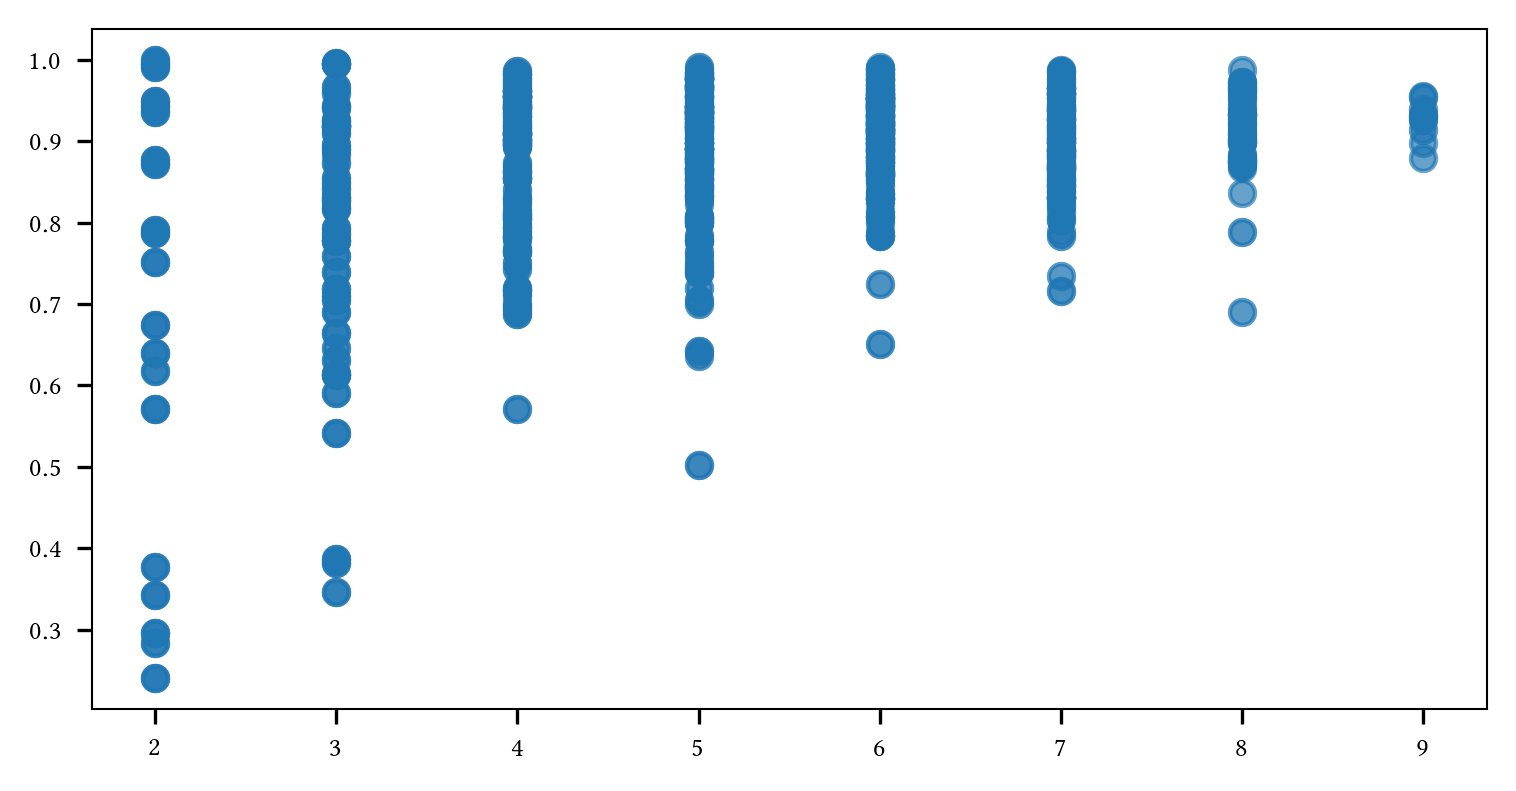

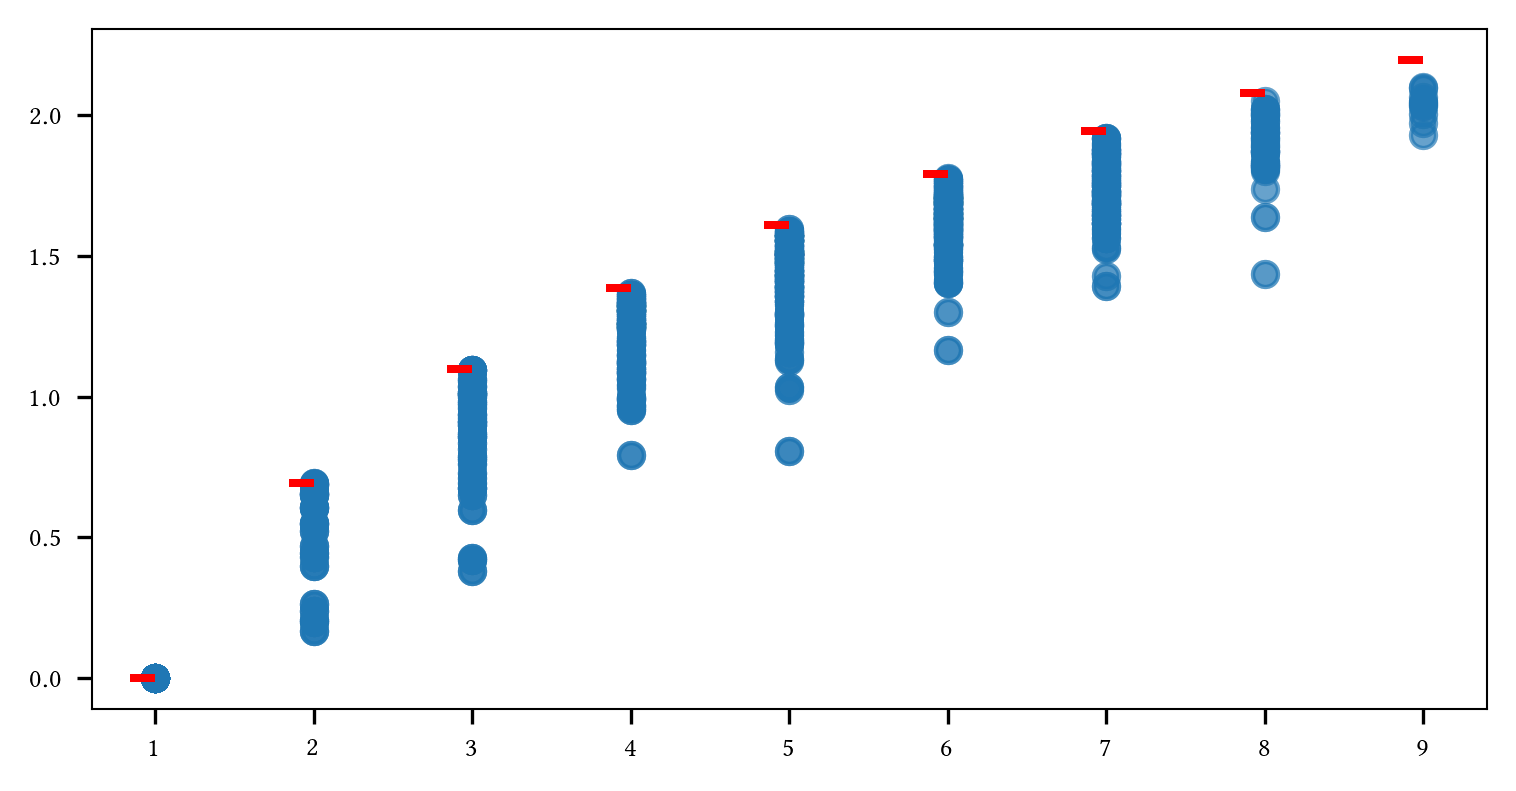

In [53]:
from scipy.stats import entropy
superagent_sizes = [r[1] for r in results_environmental]
superagent_env_det_info = [r[0] for r in results_environmental]
superagent_contribution_entropies = [entropy(contributions) for contributions in all_contributions]

plt.figure(figsize=(6, 3), dpi=150)
plt.scatter(
    superagent_sizes, 
    superagent_env_det_info, 
    alpha=0.3, 
    c=superagent_contribution_entropies/np.log(superagent_sizes),
    cmap='viridis', 
    label="Environmental Determined Individuality"
)


plt.figure(figsize=(6, 3), dpi=150)
plt.scatter(
    superagent_sizes, 
    superagent_contribution_entropies/np.log(superagent_sizes), 
    alpha=0.2, 
    # c=superagent_env_det_info,
    cmap='viridis', 
    label="Environmental Determined Individuality"
)

plt.figure(figsize=(6, 3), dpi=150)
plt.scatter(
    superagent_sizes, 
    superagent_contribution_entropies, 
    alpha=0.2, 
    # c=superagent_env_det_info,
    cmap='viridis', 
    label="Environmental Determined Individuality"
)
plt.scatter(
    superagent_sizes, 
    np.log(superagent_sizes), 
    c='red', 
    marker=0,
    zorder=10
)

## IDEA: optimise linear coarse-graining function $V$ w.r.t. $\Psi$

Let:
$$
V = \sum_i w_i X^i
$$

Optimise $w_i$ w.r.t. $\Psi$.

$$
\Psi = I(V_t; V_{t+1}) - \sum_i I(X^i_t; V_{t+1})
$$

In [ ]:
# from scipy.optimize import minimize

# # Define the objective function for optimization
# def psi_objective(w, X, num_bins=10):
#     """
#     Objective function to minimize Psi = I(V_t; V_{t+1}) - sum_i I(X^i_t; V_{t+1})
#     """
#     # Compute V = sum_i w_i * X^i
#     V = X @ w

#     # Compute the first term: I(V_t; V_{t+1})
#     mi_estimator = JidtDiscreteMI(settings=dict(
#         n_discrete_bins=num_bins,
#         discretise_method='max_ent',
#     ))
#     source = V[:-1]
#     target = V[1:]
#     I_Vt_Vt1 = mi_estimator.estimate(source, target)

#     # Compute the second term: sum_i I(X^i_t; V_{t+1})
#     I_Xi_Vt1_sum = 0
#     for i in range(X.shape[1]):
#         source = X[:-1, i]
#         target = V[1:]
#         I_Xi_Vt1_sum += mi_estimator.estimate(source, target)

#     # Compute Psi
#     psi = I_Vt_Vt1 - I_Xi_Vt1_sum

#     return -psi  # Minimize negative Psi to maximize Psi

In [ ]:
# for superagent_idx in range(len(all_partition_timeseries)):

#     data = all_partition_timeseries[superagent_idx]
#     X = data[0]
#     Y = data[1]

#     # Initialize weights
#     num_features = X.shape[1]
#     initial_weights = np.ones(num_features) / num_features

#     # Optimize weights
#     result = minimize(
#         psi_objective, 
#         initial_weights, 
#         args=(X), 
#         method='L-BFGS-B', 
#         bounds=[(0, 1)] * num_features,
#         tol=1e-6,
#         options={'disp': True}
#     )

#     # Extract optimized weights
#     optimized_weights = result.x
#     print("Optimized weights:", optimized_weights)

#     # Compute the final V using the optimized weights
#     V_optimized = X @ optimized_weights

Optimized weights: [1.]
Optimized weights: [1.]
Optimized weights: [1.]
Optimized weights: [1.]
Optimized weights: [1.]
Optimized weights: [0.5 0.5]
Optimized weights: [0.5 0.5]
Optimized weights: [0.5 0.5]
Optimized weights: [0.5 0.5]
Optimized weights: [0.5 0.5]
Optimized weights: [0.5 0.5]
Optimized weights: [0.5 0.5]
Optimized weights: [0.5 0.5]
Optimized weights: [0.33333333 0.33333333 0.33333333]
Optimized weights: [0.33333333 0.33333333 0.33333333]
Optimized weights: [0.33333762 0.33333119 0.33333762]
Optimized weights: [0.33333333 0.33333333 0.33333333]
Optimized weights: [0.33333333 0.33333333 0.33333333]
Optimized weights: [0.33333333 0.33333333 0.33333333]
Optimized weights: [0.33333333 0.33333333 0.33333333]
Optimized weights: [0.33333333 0.33333333 0.33333333]
Optimized weights: [0.33333333 0.33333333 0.33333333]
Optimized weights: [0.33333333 0.33333333 0.33333333]
Optimized weights: [0.25 0.25 0.25 0.25]
Optimized weights: [0.2500021 0.2500021 0.2500021 0.2499993]
Optimi

KeyboardInterrupt: 

## epsilon Machines, D-BaSS

In [55]:
from collections import Counter
import numpy as np

**Minimal D-BaSS** ([@Rosas2020CausalBlankets](http://arxiv.org/abs/2008.12568)):

Given stochastic process $\boldsymbol{X}$, $\boldsymbol{Y}$, the minimal D-BaSS of $\boldsymbol{X}$ w.r.t. $\boldsymbol{Y}$ corresponds to the partition of past-trajectories $\boldsymbol{x}_t$ induced by the following equivalence relationship:
$$\boldsymbol{x}_t \equiv_p \boldsymbol{x}'_t$$ 
iff $\forall \boldsymbol{y}_t, y_{t+1}$, 
$$p(y_{t+1} | \boldsymbol{x}_t, \boldsymbol{y}_t) = p(y_{t+1} | \boldsymbol{x}'_t, \boldsymbol{y}_t)$$

In [ ]:
from collections import Counter
import numpy as np
from scipy.stats import entropy

def estimate_conditional_probabilities(X, Y, L=1):
    '''
    Estimate p(y_{t+1} | x_{t-L:t}, y_{t-L:t})
    '''

    T = X.shape[0]
    n = X.shape[1]
    m = Y.shape[1]
        
    # Generate subsequences
    X_subsequences = np.array([X[t-L:t] for t in range(L, len(X))])  # shape: (T-L+1, L, n)
    Y_subsequences = np.array([Y[t-L:t] for t in range(L, len(Y))])  # shape: (T-L+1, L, m)

    # Flatten subsequences for input to the model
    X_sub_flat = X_subsequences.reshape(X_subsequences.shape[0], -1)  # shape: (T-L+1, L*n)
    Y_sub_flat = Y_subsequences.reshape(Y_subsequences.shape[0], -1)  # shape: (T-L+1, L*m)

    # Combine X_sub and Y_sub as features
    features = np.hstack((X_sub_flat, Y_sub_flat))  # { X_{t-L:t}, Y_{t-L:t} }  shape: (T-L+1, L*n + L*m)

    # Target is the current state Y
    targets = Y[L:]  # { Y_{t} }  shape: (T-L+1, m)

    # Convert features and targets to tuples for counting
    features_tuples = [tuple(f) for f in features]
    target_tuples = [tuple(t) for t in targets]

    # Count occurrences of each feature-target pair, and of each feature
    joint_counts = Counter(zip(features_tuples, target_tuples))
    feature_counts = Counter(features_tuples)

    # Generate the support for the probability distribution
    dist_support = (
        np.array([list(map(int, f"{i:0{m}b}")) for i in range(2**m)])
    )  # shape: (2^m, m) e.g. [[0, 0, 0], [0, 0, 1], [0, 1, 0], [0, 1, 1], [1, 0, 0], ...] for m=3

    # Estimate conditional probabilities
    conditional_probs = {
        tuple(X_L): {}  # X_L is a single length-L subsequence of X
        for X_L in np.unique(X_sub_flat, axis=0)
    }
    for (feature, target), joint_count in joint_counts.items():
        X_L = tuple(feature[:L*n])
        Y_L = tuple(feature[L*n:])
        
        # Create a new entry in the dictionary if it doesn't exist
        if conditional_probs[X_L].get(Y_L) is None:
            conditional_probs[X_L][Y_L] = np.zeros(dist_support.shape[0])
        
        # Update the conditional probability for the target
        target_index = np.where((dist_support == target).all(axis=1))[0][0]
        conditional_probs[X_L][Y_L][target_index] = joint_count / feature_counts[feature]

    return dist_support, X_sub_flat, Y_sub_flat, conditional_probs

In [66]:
def get_minimal_DBaSS(X_sub_flat, conditional_probs, epsilon=1e-3):
    """
    Get the minimal D-BaSS causal states for a given set of conditional probabilities.

    Args:
        X_sub_flat (np.ndarray): The flattened subsequences of X (shape: (T-L+1, L*n)).
        conditional_probs (dict): The conditional probabilities p(y | X_L, Y_L) for each subsequence X_L.
        epsilon (float): The threshold for KL divergence to determine if two distributions are similar.
    """
    causal_states = []  # The list of causal states grows as new states are "discovered"
    for X_L in X_sub_flat:
        # Check what causal state each X_L belongs to
        X_L = tuple(X_L)
        for causal_state in causal_states:
            match = True
            # Check if the current X_L matches any existing causal state (for all Y_L and y)
            for Y_L in conditional_probs[X_L].keys():
                support_length = conditional_probs[X_L][Y_L].shape[0]
                target_distribution = (  # p(y | X_L, Y_L)
                    causal_state['distributions']
                    .get(
                        Y_L, # Retrieve the "canonical" distribution for Y_L under this causal state
                        np.ones(support_length) / support_length  # If Y_L is not found, use MaxEnt distribution (FIXME?)
                    )
                )  
                KL_divergence = entropy(
                    conditional_probs[X_L][Y_L], 
                    target_distribution
                )
                if KL_divergence > epsilon:
                    match = False
                    break  # No match, move on to the next causal state
            if match:  # Distributions for all Y_L matched
                # Add the current X_L to the members of the matching causal state
                causal_state['members'].add(X_L)
                # Update the canonical distribution for the matching causal state
                # TODO: is this necessary?
                causal_state['distributions'].update(conditional_probs[X_L])
                break
        # Having exhausted all causal states, if no match was found, create a new one
        if len(causal_states) == 0 or not match:
            causal_states.append({
                'members': {X_L},
                'distributions': conditional_probs[X_L],
                'label': len(causal_states),  # Label the new causal state
            })

    return causal_states

In [78]:
from tqdm import tqdm

num_bins = 10
mi_estimator = JidtDiscreteMI(settings=dict(
    n_discrete_bins=num_bins,
    discretise_method='max_ent',
))

all_empowerments = []
# superagent_idx = 30
for i in tqdm(range(len(all_partition_timeseries))):
    superagent_idx = i
    data = all_partition_timeseries[superagent_idx]

    X = data[0]
    Y = data[1]

    # Compute the Causal Blanket states ----------------------------------------
    _, X_sub_flat, Y_sub_flat, conditional_probs = estimate_conditional_probabilities(X, Y, L=1)
    A_causal_states = get_minimal_DBaSS(X_sub_flat, conditional_probs)

    _, Y_sub_flat, X_sub_flat, conditional_probs = estimate_conditional_probabilities(Y, X, L=1)
    S_causal_states = get_minimal_DBaSS(Y_sub_flat, conditional_probs)
    
    # print(f'Superagent {superagent_idx} (n={X.shape[1]}, m={Y.shape[1]}). |A|={len(A_causal_states)}, |S|={len(S_causal_states)}') 
    # print([len(cs['members']) for cs in S_causal_states], [len(cs['members']) for cs in A_causal_states])

    # Get timeseries of causal state labels ------------------------------------
    A_cs = np.empty(X_sub_flat.shape[0], dtype=int)
    for t, X_L in enumerate(X_sub_flat):
        X_L = tuple(X_L)
        for causal_state in A_causal_states:
            if X_L in causal_state['members']:
                A_cs[t] = causal_state['label']
                break
    
    S_cs = np.empty(Y_sub_flat.shape[0], dtype=int)
    for t, Y_L in enumerate(Y_sub_flat):
        Y_L = tuple(Y_L)
        for causal_state in S_causal_states:
            if Y_L in causal_state['members']:
                S_cs[t] = causal_state['label']
                break

    # Compute empowerment --------------------------------------------------------
    # NOTE: empowerment is actually the channel capacity max_p(a) I(A_t; S_{t+1}),
    #       but here we only compute I(A_t; S_{t+1})
    source = A_cs[:-1]
    target = S_cs[1:]
    empowerment = mi_estimator.estimate(source, target)  # I(A_t; S_{t+1})
    all_empowerments.append(empowerment)


100%|██████████| 4988/4988 [09:52<00:00,  8.41it/s]


Text(0.5, 1.0, 'Empowerment vs. Size of Superagent (data for 4988 superagents)')

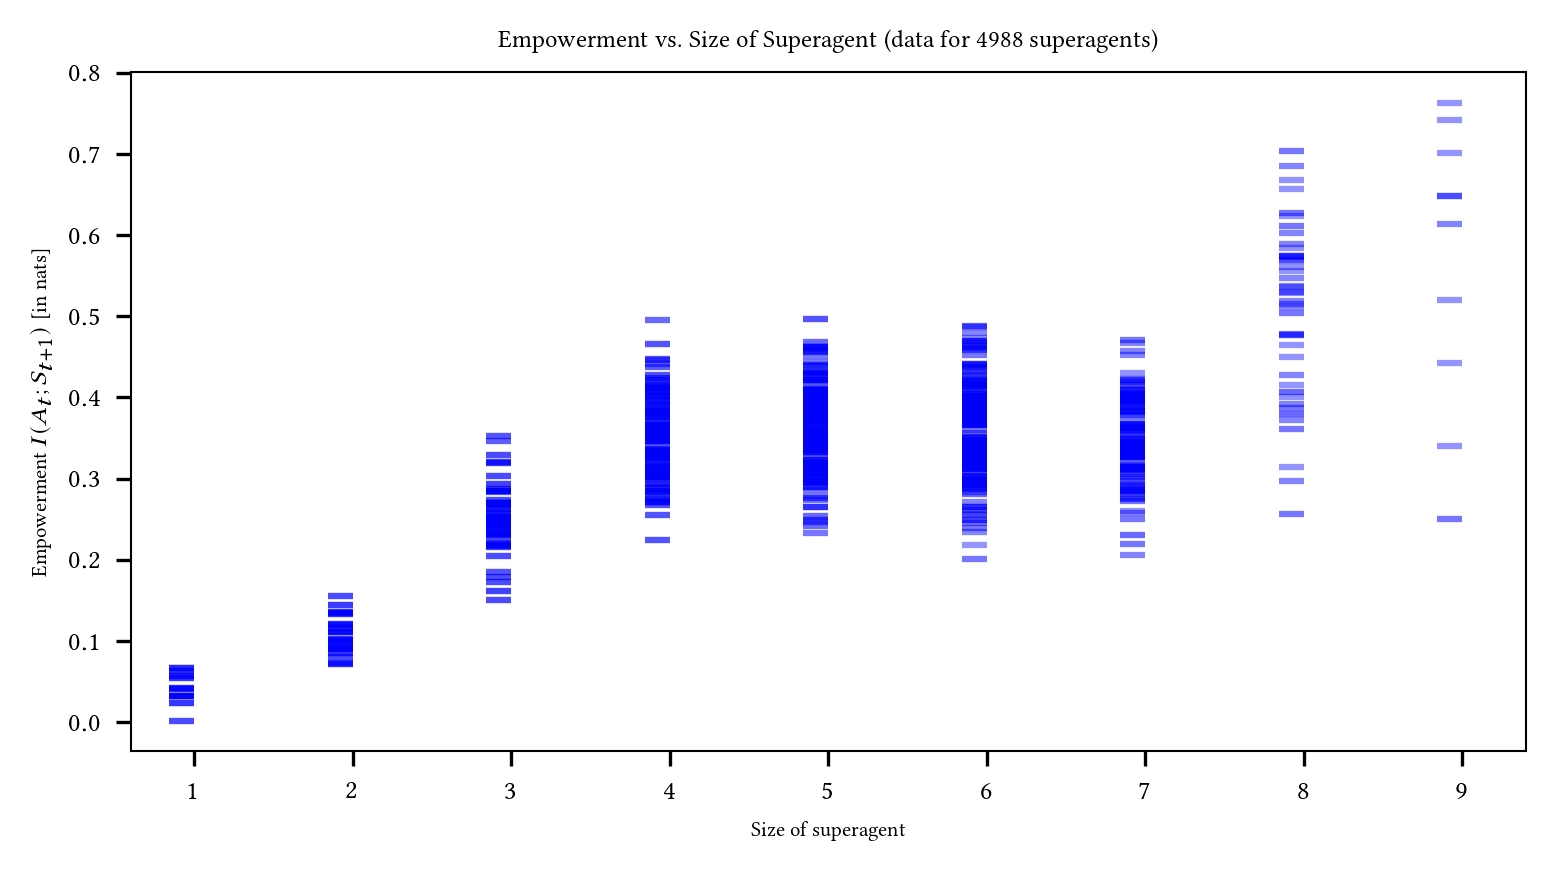

In [83]:
all_empowerments = np.array(all_empowerments)
plt.figure(figsize=(6, 3), dpi=150)
plt.scatter(
    superagent_sizes, 
    all_empowerments, 
    alpha=0.1, 
    c='blue', 
    marker=0,
    label="Empowerment"
)
plt.xlabel('Size of superagent')
plt.ylabel(r'Empowerment $I(A_t; S_{t+1})$ [in nats]')
plt.title(f'Empowerment vs. Size of Superagent (data for {len(all_empowerments)} superagents)')

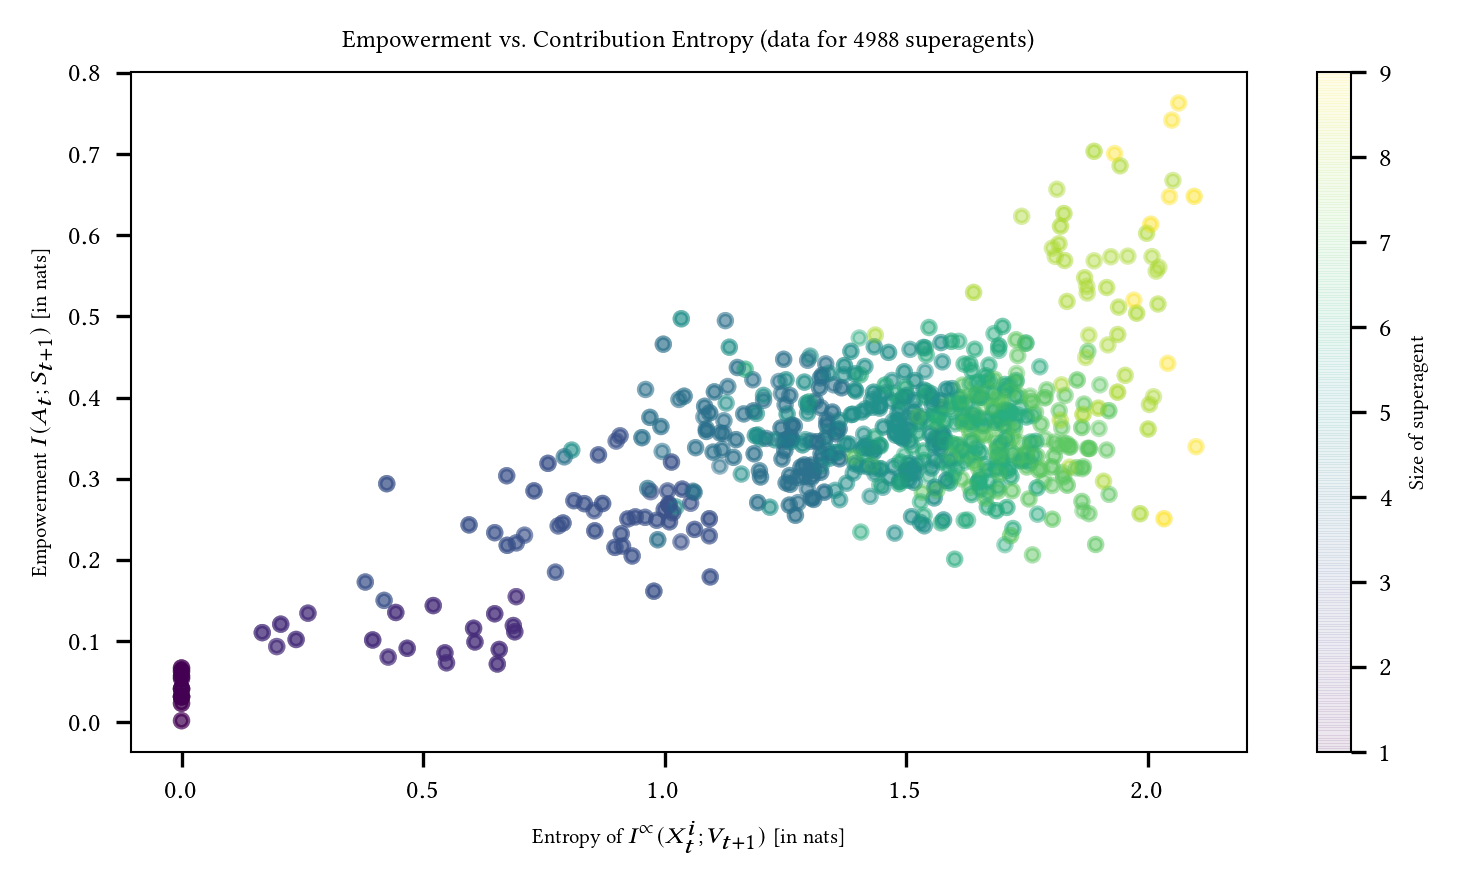

In [102]:
plt.figure(figsize=(6, 3), dpi=150)
plt.scatter(
    superagent_contribution_entropies,#/np.log(superagent_sizes), 
    all_empowerments, 
    alpha=0.1, 
    c=superagent_sizes,
    s=10,
    cmap='viridis', 
    label="Environmental Determined Individuality"
)
plt.xlabel(r'Entropy of $I^{\propto}(X^i_t; V_{t+1})$ [in nats]')
plt.ylabel(r'Empowerment $I(A_t; S_{t+1})$ [in nats]')
plt.title(f'Empowerment vs. Contribution Entropy (data for {len(all_empowerments)} superagents)')
plt.colorbar(label='Size of superagent')
plt.show()

## Empowerment

$$
\mathfrak{E} \triangleq C(A_t \to S_{t+1}) \equiv \max_{p(a_t)} I(S_{t+1}; A_t)
$$

ModuleNotFoundError: No module named 'idtxl.mutual_information'

In [ ]:
# --- Example Usage ---
# Generate some sample multivariate data
num_samples = 500
num_s_vars = 2  # e.g., position (x, y)
num_a_vars = 2  # e.g., force (fx, fy)

np.random.seed(123)
a_data = np.random.randn(num_samples, num_a_vars) * 5 # Random actions

# Create simple dynamics: S_{t+1} = S_t + 0.1*A_t + noise
s_data = np.zeros((num_samples, num_s_vars))
noise_std = 0.5
integration_factor = 0.1
for t in range(num_samples - 1):
    # Assume action affects acceleration, integrate simply
    # Ensure action dimension matches state dimension influence if necessary
    # Here, let's assume A[0] influences S[0], A[1] influences S[1]
    s_data[t+1, :] = s_data[t, :] + integration_factor * a_data[t, :num_s_vars] + np.random.normal(0, noise_std, size=num_s_vars)

# --- Compute the MI ---
mi_s_next_a_current = compute_multivariate_mi_s_next_a_current(s_data, a_data, k=5, verbose=False)

if mi_s_next_a_current is not None:
    print(f"\nEstimated Multivariate Mutual Information I(S_t+1 ; A_t) = {mi_s_next_a_current:.4f} nats")
    print("\nReminder: This measures the information based on observed data, not 'Empowerment'.")
else:
    print("\nFailed to compute Mutual Information.")

# --- Example with mismatched dimensions (should raise error) ---
# print("\n--- Testing Mismatched Samples Error ---")
# try:
#     s_short = s_data[:-10, :]
#     compute_multivariate_mi_s_next_a_current(s_short, a_data)
# except ValueError as e:
#     print(f"Caught expected error: {e}")